In [31]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt
import numpy as np

In [76]:
# Load the trajectory and topology files
u = mda.Universe('/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.prmtop', '/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/Analysis/6-md_auto.nc')
#ref = mda.Universe('/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.prmtop','/data/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/WT/MD_Replica/EFE_solv.pdb')
len(u.trajectory)

10000

In [77]:
# Calculate RMSD
rmsd = rms.RMSD(u, u, ref_frame=0, select='backbone')
rmsd.run()

# Convert frames to time
time_step = 0.1  # time step in nanoseconds
time = np.arange(len(rmsd.rmsd)) * time_step

# Calculate average RMSD
average_rmsd = np.mean(rmsd.rmsd[:, 2])

# Create a DataFrame with time and RMSD values
rmsd_df = pd.DataFrame({
    'Time (ns)': time,
    'RMSD (Å)': rmsd.rmsd[:, 2]
})

In [78]:

# Print the DataFrame and average RMSD
print("RMSD DataFrame:")
print(rmsd_df)
print(f"\nAverage RMSD: {average_rmsd:.2f} Å")

RMSD DataFrame:
      Time (ns)      RMSD (Å)
0           0.0  2.930051e-07
1           0.1  8.392854e-01
2           0.2  8.311177e-01
3           0.3  9.317016e-01
4           0.4  8.391863e-01
...         ...           ...
9995      999.5  2.016767e+00
9996      999.6  2.123876e+00
9997      999.7  2.039173e+00
9998      999.8  2.164509e+00
9999      999.9  2.072564e+00

[10000 rows x 2 columns]

Average RMSD: 1.67 Å


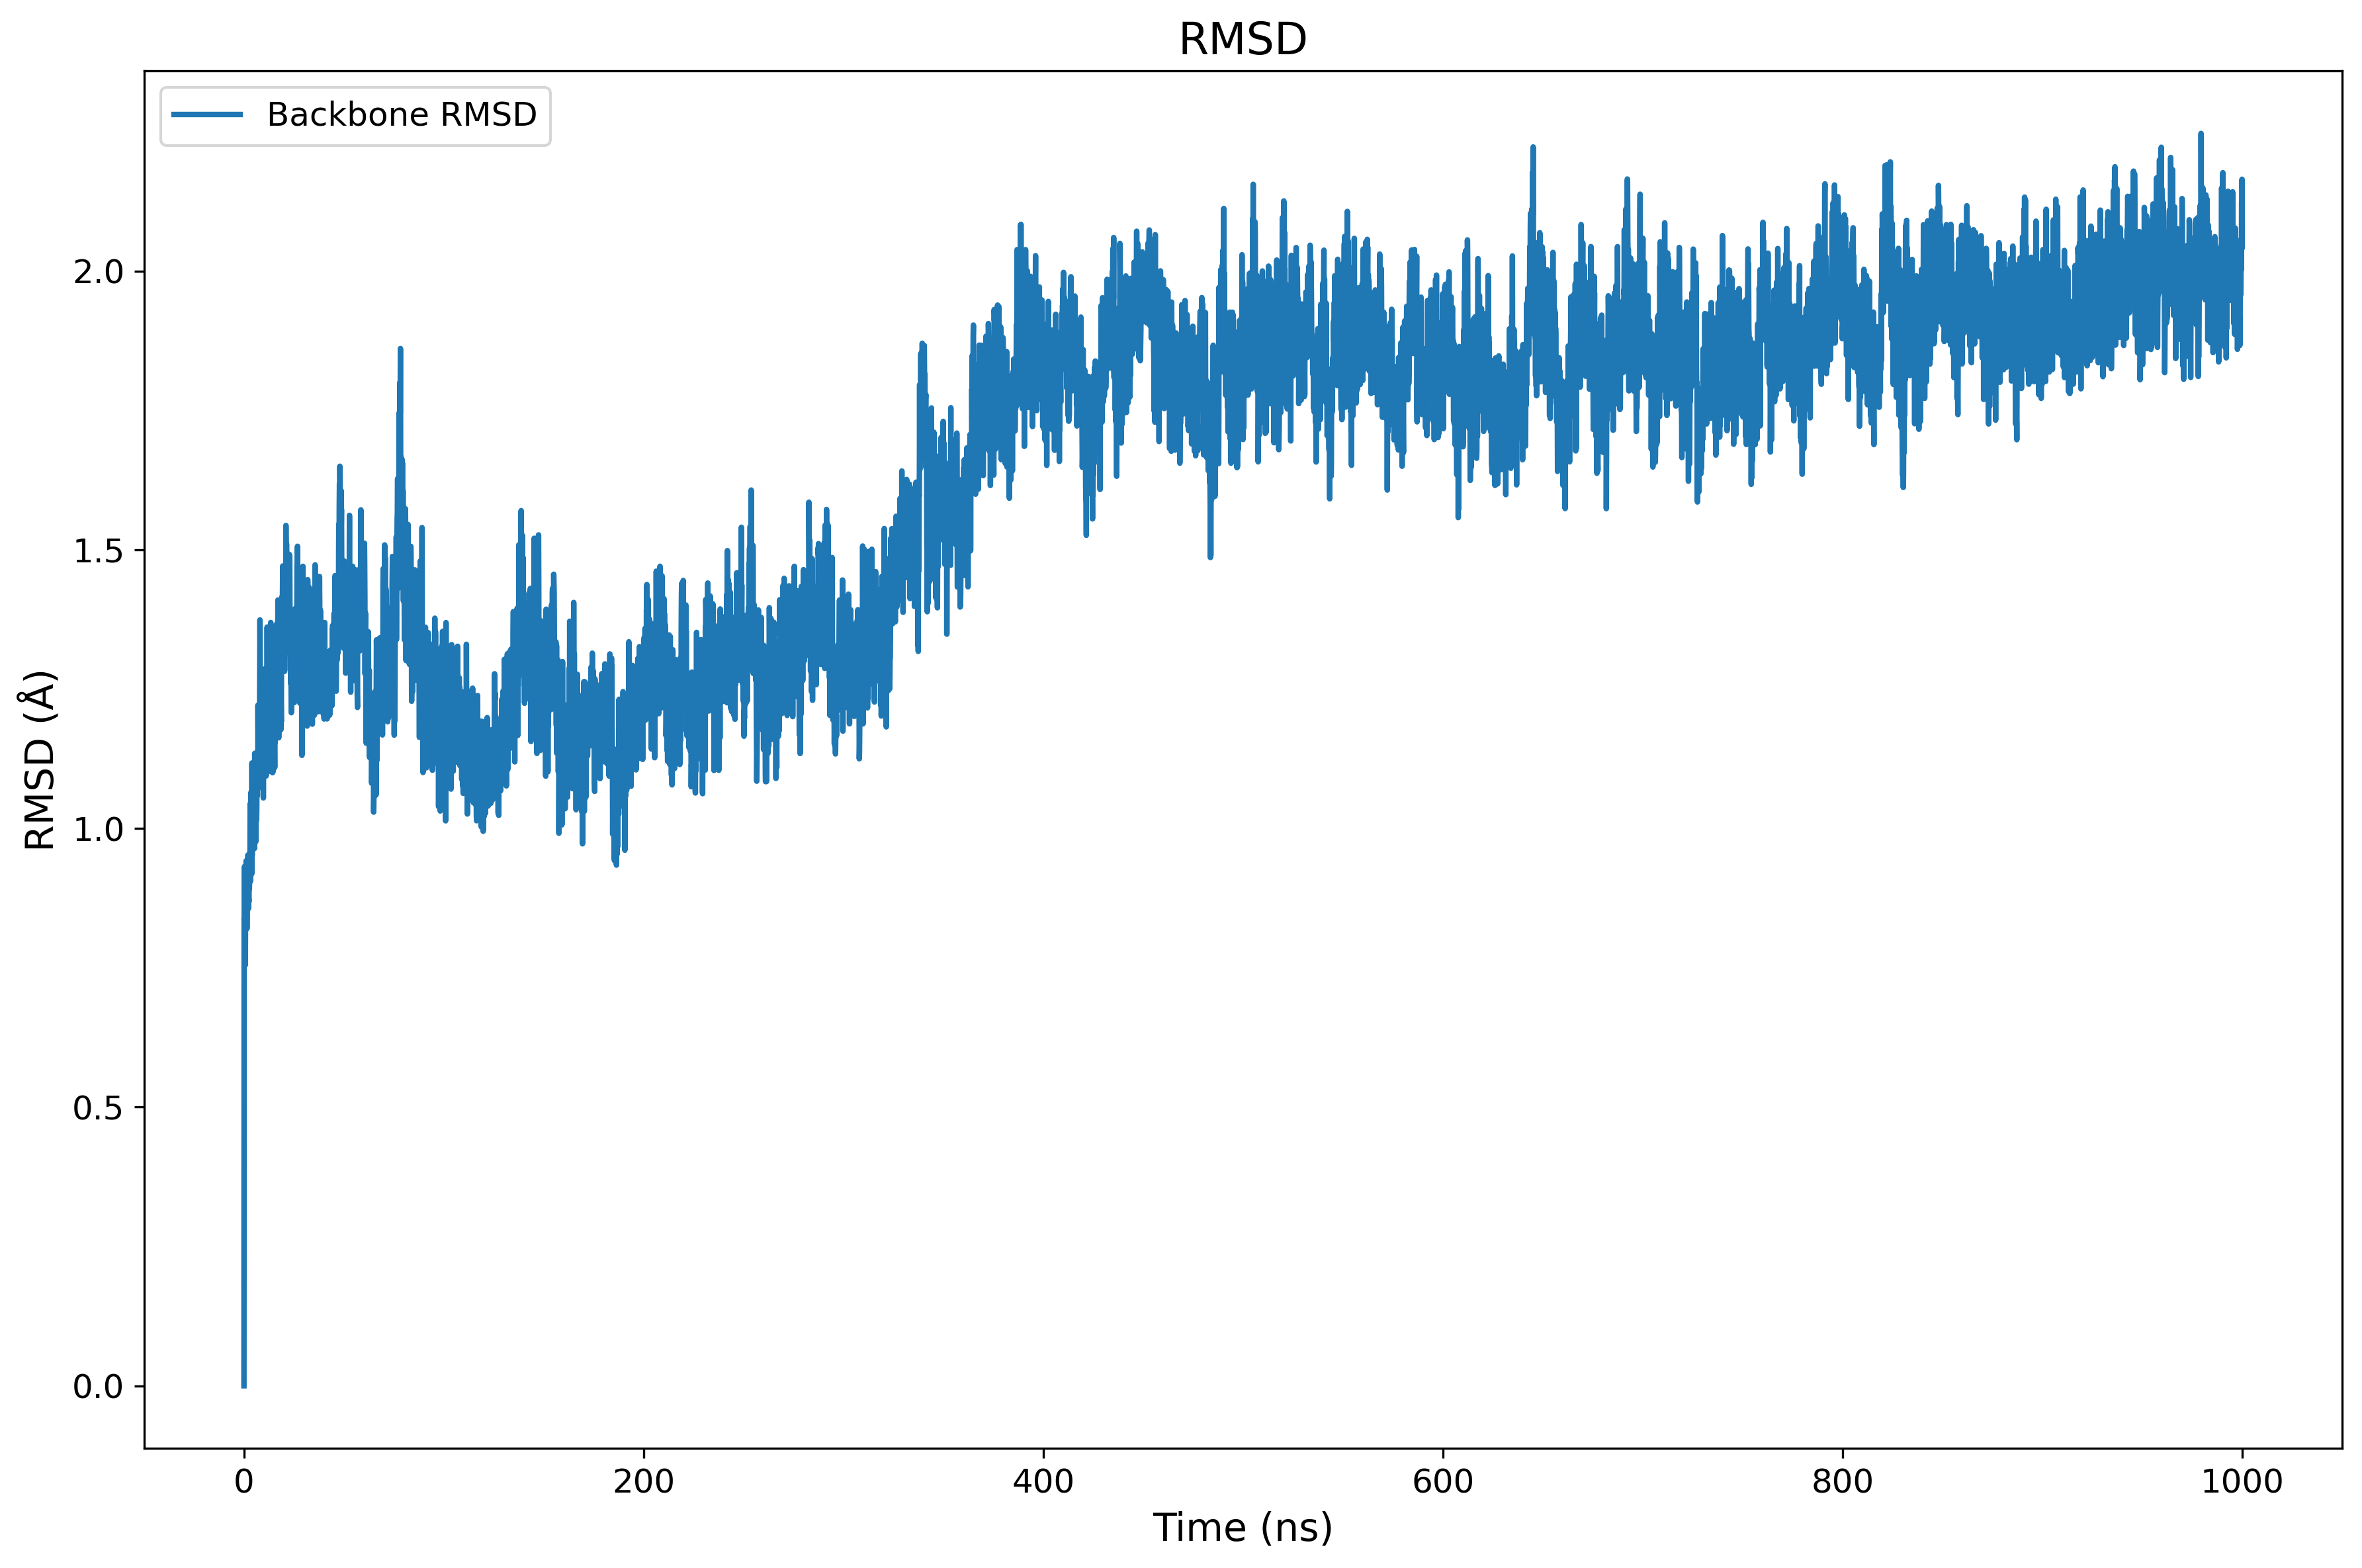

In [79]:
# Configure Matplotlib to use Arial font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
# Plot RMSD with high quality settings
plt.figure(figsize=(12, 8), dpi=300)  # Set figure size and resolution
plt.plot(time, rmsd.rmsd[:, 2], label='Backbone RMSD', linewidth=2)
plt.xlabel('Time (ns)', fontsize=14)
plt.ylabel('RMSD (Å)', fontsize=14)
plt.title('RMSD', fontsize=16)
plt.legend(fontsize=12)
plt.grid(False)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [81]:
# Calculate RMSF
rmsf = rms.RMSF(u.select_atoms('name CA')).run()
rmsf_values = rmsf.rmsf